In [21]:
import pandas as pd
import numpy as np
import re
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from snownlp import SnowNLP
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（macOS兼容）
import matplotlib.font_manager as fm
import platform

# 根据操作系统选择合适的中文字体
if platform.system() == 'Darwin':  # macOS
    # macOS上可用的中文字体
    chinese_fonts = ['PingFang SC', 'PingFang HK', 'STHeiti', 'STSong', 'Arial Unicode MS', 'Heiti SC']
elif platform.system() == 'Windows':
    # Windows上可用的中文字体
    chinese_fonts = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
else:  # Linux
    # Linux上可用的中文字体
    chinese_fonts = ['WenQuanYi Micro Hei', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC']

# 设置字体，如果找不到就使用默认字体
plt.rcParams['font.sans-serif'] = chinese_fonts + ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 验证字体是否设置成功
print("字体配置:")
print(f"  操作系统: {platform.system()}")
print(f"  使用字体列表: {chinese_fonts[:3]}...")
print(f"  当前字体: {plt.rcParams['font.sans-serif'][0]}")
print("✓ 字体配置完成\n")

字体配置:
  操作系统: Darwin
  使用字体列表: ['PingFang SC', 'PingFang HK', 'STHeiti']...
  当前字体: PingFang SC
✓ 字体配置完成



In [22]:
# 读取数据
print("=" * 60)
print("步骤1: 读取数据...")
print("=" * 60)
df = pd.read_csv("clustered_data.csv")
print(f"✓ 数据读取完成！")
print(f"  - 总评论数: {len(df)} 条")
print(f"  - 数据列数: {len(df.columns)} 列")
print(f"  - 数据列名: {', '.join(df.columns.tolist())}")
print(f"\n前3条数据预览:")
print(df.head(3).to_string())
print("\n")

步骤1: 读取数据...
✓ 数据读取完成！
  - 总评论数: 3514 条
  - 数据列数: 5 列
  - 数据列名: nickname, cleaned_content, content_length, like_count, evaluation_dimension

前3条数据预览:
     nickname                                              cleaned_content  content_length  like_count evaluation_dimension
0         一点点                                    哈哈哈 蛟龙16pro虽然声音非常大 性能确实不错              25         0.0                性能,噪音
1    朝花夕拾，叹离别                          确实不太行 小问题多 不过就是便宜 大多数板材都用的性价比材料相对便宜              35         0.0                  性价比
2  每月400零用笑哈哈  是不是开了性能模式 我下载东西时会开办公模式。开性能模式不知道为什么突然风扇就会像玩游戏一样大声。我的是蛟龙15pro              59         0.0                性能,噪音




In [23]:
# 文本预处理
print("=" * 60)
print("步骤2: 文本预处理...")
print("=" * 60)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'[^\w\u4e00-\u9fa5]', ' ', str(text))
    return ' '.join(jieba.cut(text))

print("正在预处理文本（jieba分词 + 文本清洗）...")
df['cleaned_text'] = df['cleaned_content'].apply(clean_text)
print(f"✓ 文本预处理完成！")
print(f"\n预处理示例（前3条）:")
for i in range(min(3, len(df))):
    print(f"\n原始文本 {i+1}:")
    print(f"  {df.iloc[i]['cleaned_content'][:100]}...")
    print(f"处理后文本 {i+1}:")
    print(f"  {df.iloc[i]['cleaned_text'][:100]}...")
print("\n")


步骤2: 文本预处理...
正在预处理文本（jieba分词 + 文本清洗）...
✓ 文本预处理完成！

预处理示例（前3条）:

原始文本 1:
  哈哈哈 蛟龙16pro虽然声音非常大 性能确实不错...
处理后文本 1:
  哈哈哈   蛟龙 16pro 虽然 声音 非常 大   性能 确实 不错...

原始文本 2:
  确实不太行 小问题多 不过就是便宜 大多数板材都用的性价比材料相对便宜...
处理后文本 2:
  确实 不 太行   小 问题 多   不过 就是 便宜   大多数 板材 都 用 的 性价比 材料 相对 便宜...

原始文本 3:
  是不是开了性能模式 我下载东西时会开办公模式。开性能模式不知道为什么突然风扇就会像玩游戏一样大声。我的是蛟龙15pro...
处理后文本 3:
  是不是 开 了 性能 模式   我 下载 东西 时会 开 办公 模式   开 性能 模式 不 知道 为什么 突然 风扇 就 会 像 玩游戏 一样 大声   我 的 是 蛟龙 15pro...




In [ ]:
# 情感分析
print("=" * 60)
print("步骤3: 情感分析...")
print("=" * 60)

def get_sentiment(text):
    if not text or text == "":
        return 0.5, 'neutral'
    try:
        s = SnowNLP(text)
        score = s.sentiments
        if score > 0.6:
            sentiment = 'positive'
        elif score < 0.4:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
        return score, sentiment
    except:
        return 0.5, 'neutral'

df['sentiment_score'], df['sentiment'] = zip(*df['cleaned_text'].apply(get_sentiment))
print(f"✓ 情感分析完成！")

# 打印情感分布统计
sentiment_counts = df['sentiment'].value_counts()
print(f"\n情感分布统计:")
for sentiment, count in sentiment_counts.items():
    percentage = count / len(df) * 100
    print(f"  {sentiment:8s}: {count:4d} 条 ({percentage:5.2f}%)")

print(f"\n情感得分统计:")
print(f"  平均得分: {df['sentiment_score'].mean():.3f}")
print(f"  最高得分: {df['sentiment_score'].max():.3f}")
print(f"  最低得分: {df['sentiment_score'].min():.3f}")
print("\n")

步骤3: 情感分析...
正在使用SnowNLP进行情感分析...
✓ 情感分析完成！

情感分布统计:
  positive: 1568 条 (44.62%)
  negative: 1555 条 (44.25%)
  neutral :  391 条 (11.13%)

情感得分统计:
  平均得分: 0.493
  最高得分: 1.000
  最低得分: 0.000




In [25]:
# 质量相关的细分类别
print("=" * 60)
print("步骤4: 质量问题检测...")
print("=" * 60)

quality_categories = {
    '硬件故障': ['故障', '坏掉', '损坏', '烧坏', '不工作', '开不了机', '死机', '蓝屏', '重启'],
    '做工问题': ['做工', '缝隙', '松动', '毛刺', '划痕', '瑕疵', '粗糙', '工艺'],
    '小毛病': ['小毛病', '小问题', '小bug', '小缺陷', '小瑕疵', '不影响使用'],
    '散热问题': ['散热', '发热', '发烫', '温度', '过热', '烫手', '风扇'],
    '噪音问题': ['噪音', '声音', '吵', '响', '轰鸣', '异响'],
    '屏幕问题': ['屏幕', '显示', '亮点', '暗点', '漏光', '色差', '闪烁'],
    '电池问题': ['电池', '续航', '耗电', '充电', '电量', '待机'],
    '性能问题': ['卡顿', '卡死', '慢', '延迟', '反应慢', '不流畅']
}

print(f"定义的质量问题类别: {len(quality_categories)} 类")
for category, keywords in quality_categories.items():
    print(f"  - {category}: {len(keywords)} 个关键词")

# 检测质量相关评论
def detect_quality_issues(text):
    issues = []
    text_lower = text.lower()
    
    for category, keywords in quality_categories.items():
        if any(keyword in text_lower for keyword in keywords):
            issues.append(category)
    
    return issues

print("\n正在检测质量问题...")
df['quality_issues'] = df['cleaned_text'].apply(detect_quality_issues)
print(f"✓ 质量问题检测完成！")

# 统计质量问题
all_issues = []
for issues in df['quality_issues']:
    all_issues.extend(issues)

if all_issues:
    issue_counts = pd.Series(all_issues).value_counts()
    print(f"\n质量问题统计（共检测到 {len(all_issues)} 次问题）:")
    for issue, count in issue_counts.items():
        percentage = count / len(df) * 100
        print(f"  {issue:8s}: {count:4d} 次 ({percentage:5.2f}%)")
    
    # 统计包含质量问题的评论数
    comments_with_issues = df[df['quality_issues'].apply(lambda x: len(x) > 0)]
    print(f"\n包含质量问题的评论: {len(comments_with_issues)} 条 ({len(comments_with_issues)/len(df)*100:.2f}%)")
else:
    print("\n未检测到质量问题")

print("\n")

步骤4: 质量问题检测...
定义的质量问题类别: 8 类
  - 硬件故障: 9 个关键词
  - 做工问题: 8 个关键词
  - 小毛病: 6 个关键词
  - 散热问题: 7 个关键词
  - 噪音问题: 6 个关键词
  - 屏幕问题: 7 个关键词
  - 电池问题: 6 个关键词
  - 性能问题: 6 个关键词

正在检测质量问题...
✓ 质量问题检测完成！

质量问题统计（共检测到 1069 次问题）:
  散热问题    :  228 次 ( 6.49%)
  噪音问题    :  179 次 ( 5.09%)
  硬件故障    :  166 次 ( 4.72%)
  电池问题    :  159 次 ( 4.52%)
  屏幕问题    :  126 次 ( 3.59%)
  小毛病     :   89 次 ( 2.53%)
  性能问题    :   87 次 ( 2.48%)
  做工问题    :   35 次 ( 1.00%)

包含质量问题的评论: 787 条 (22.40%)




In [26]:
# 聚类分析
print("=" * 60)
print("步骤5: 文本聚类分析...")
print("=" * 60)

print("正在生成TF-IDF特征矩阵...")
tfidf = TfidfVectorizer(max_features=500, stop_words=['的', '了', '是', '在'])
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])
print(f"✓ TF-IDF矩阵生成完成！")
print(f"  - 特征维度: {tfidf_matrix.shape}")
print(f"  - 特征数量: {tfidf_matrix.shape[1]} 维")

print("\n正在进行K-means聚类（5个簇）...")
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)
print(f"✓ 聚类完成！")

# 打印聚类分布
cluster_counts = df['cluster'].value_counts().sort_index()
print(f"\n聚类分布:")
for cluster_id, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(f"  簇 {cluster_id}: {count:4d} 条评论 ({percentage:5.2f}%)")

# 提取每个聚类的关键词
def get_cluster_keywords(df, tfidf, kmeans, n_words=8):
    feature_names = tfidf.get_feature_names_out()
    cluster_keywords = {}
    
    for i in range(kmeans.n_clusters):
        center = kmeans.cluster_centers_[i]
        top_indices = center.argsort()[-n_words:][::-1]
        keywords = [feature_names[idx] for idx in top_indices]
        cluster_keywords[i] = keywords
    
    return cluster_keywords

print("\n正在提取各聚类的关键词...")
cluster_keywords = get_cluster_keywords(df, tfidf, kmeans)
print(f"✓ 关键词提取完成！")

print(f"\n各聚类关键词（前8个）:")
for cluster_id, keywords in cluster_keywords.items():
    print(f"  簇 {cluster_id}: {', '.join(keywords)}")
print("\n")

步骤5: 文本聚类分析...
正在生成TF-IDF特征矩阵...
✓ TF-IDF矩阵生成完成！
  - 特征维度: (3514, 500)
  - 特征数量: 500 维

正在进行K-means聚类（5个簇）...
✓ 聚类完成！

聚类分布:
  簇 0:  109 条评论 ( 3.10%)
  簇 1:  230 条评论 ( 6.55%)
  簇 2:  619 条评论 (17.62%)
  簇 3: 2026 条评论 (57.66%)
  簇 4:  530 条评论 (15.08%)

正在提取各聚类的关键词...
✓ 关键词提取完成！

各聚类关键词（前8个）:
  簇 0: 华硕, 天选, 机械, 革命, 还是, 售后, 极光, 联想
  簇 1: 鸡哥, 品控, 售后, 问题, 但是, 确实, 机械, 革命
  簇 2: 推荐, 预算, 游戏, 左右, 专业, 什么, 5000, 打游戏
  簇 3: 革命, 机械, 售后, 电脑, 这个, 就是, 现在, 极光
  簇 4: 问题, 没有, 一年, 就是, 自己, 现在, 出现, 售后




In [27]:
# 为聚类命名（重点关注质量问题）
print("=" * 60)
print("步骤6: 为聚类命名...")
print("=" * 60)

def name_clusters(keywords_dict):
    theme_map = {
        '硬件故障': ['故障', '坏掉', '损坏', '死机', '蓝屏', '重启'],
        '做工问题': ['做工', '缝隙', '松动', '毛刺', '划痕', '瑕疵'],
        '散热噪音': ['散热', '发热', '噪音', '风扇', '温度', '声音'],
        '性能问题': ['性能', '卡顿', '慢', '流畅', '速度', '反应'],
        '屏幕显示': ['屏幕', '显示', '色彩', '分辨率', '画质'],
        '电池续航': ['电池', '续航', '充电', '耗电', '电量'],
        '性价比': ['价格', '性价比', '便宜', '划算', '预算'],
        '售后服务': ['售后', '服务', '保修', '维修', '客服']
    }
    
    cluster_names = {}
    print("正在为各聚类匹配主题...")
    for cluster_id, keywords in keywords_dict.items():
        scores = {}
        for theme, words in theme_map.items():
            score = sum(1 for keyword in keywords if any(word in keyword for word in words))
            scores[theme] = score
        
        if scores and max(scores.values()) > 0:
            best_theme = max(scores, key=scores.get)
            cluster_names[cluster_id] = best_theme
            print(f"  簇 {cluster_id}: 匹配到主题 '{best_theme}' (得分: {scores[best_theme]})")
        else:
            # 检查质量问题
            cluster_data = df[df['cluster'] == cluster_id]
            all_issues = []
            for issues in cluster_data['quality_issues']:
                all_issues.extend(issues)
            
            if all_issues:
                issue_counts = pd.Series(all_issues).value_counts()
                if len(issue_counts) > 0:
                    cluster_names[cluster_id] = f"质量问题-{issue_counts.index[0]}"
                    print(f"  簇 {cluster_id}: 根据质量问题命名为 '{cluster_names[cluster_id]}'")
                else:
                    cluster_names[cluster_id] = f'其他{cluster_id}'
                    print(f"  簇 {cluster_id}: 命名为 '{cluster_names[cluster_id]}'")
            else:
                cluster_names[cluster_id] = f'其他{cluster_id}'
                print(f"  簇 {cluster_id}: 命名为 '{cluster_names[cluster_id]}'")
    
    return cluster_names

cluster_names = name_clusters(cluster_keywords)
df['cluster_name'] = df['cluster'].map(cluster_names)
print(f"\n✓ 聚类命名完成！")

# 打印最终聚类分布
print(f"\n最终聚类分布:")
final_cluster_counts = df['cluster_name'].value_counts()
for name, count in final_cluster_counts.items():
    percentage = count / len(df) * 100
    print(f"  {name:20s}: {count:4d} 条 ({percentage:5.2f}%)")
print("\n")

步骤6: 为聚类命名...
正在为各聚类匹配主题...
  簇 0: 匹配到主题 '售后服务' (得分: 1)
  簇 1: 匹配到主题 '售后服务' (得分: 1)
  簇 2: 匹配到主题 '性价比' (得分: 1)
  簇 3: 匹配到主题 '售后服务' (得分: 1)
  簇 4: 匹配到主题 '售后服务' (得分: 1)

✓ 聚类命名完成！

最终聚类分布:
  售后服务                : 2895 条 (82.38%)
  性价比                 :  619 条 (17.62%)




In [28]:
# 注意：详细的分析结果请查看下面的Cell 8，那里有更完整的分析输出

步骤7: 结果可视化...

=== 分析结果摘要 ===

1. 情感分布:
   positive: 1568 条 (44.62%)
   negative: 1555 条 (44.25%)
   neutral :  391 条 (11.13%)

2. 聚类分布:
   售后服务                : 2895 条 (82.38%)
   性价比                 :  619 条 (17.62%)

3. 质量问题分布（前5名）:
   散热问题    :  228 次 ( 6.49%)
   噪音问题    :  179 次 ( 5.09%)
   硬件故障    :  166 次 ( 4.72%)
   电池问题    :  159 次 ( 4.52%)
   屏幕问题    :  126 次 ( 3.59%)

正在生成可视化图表...


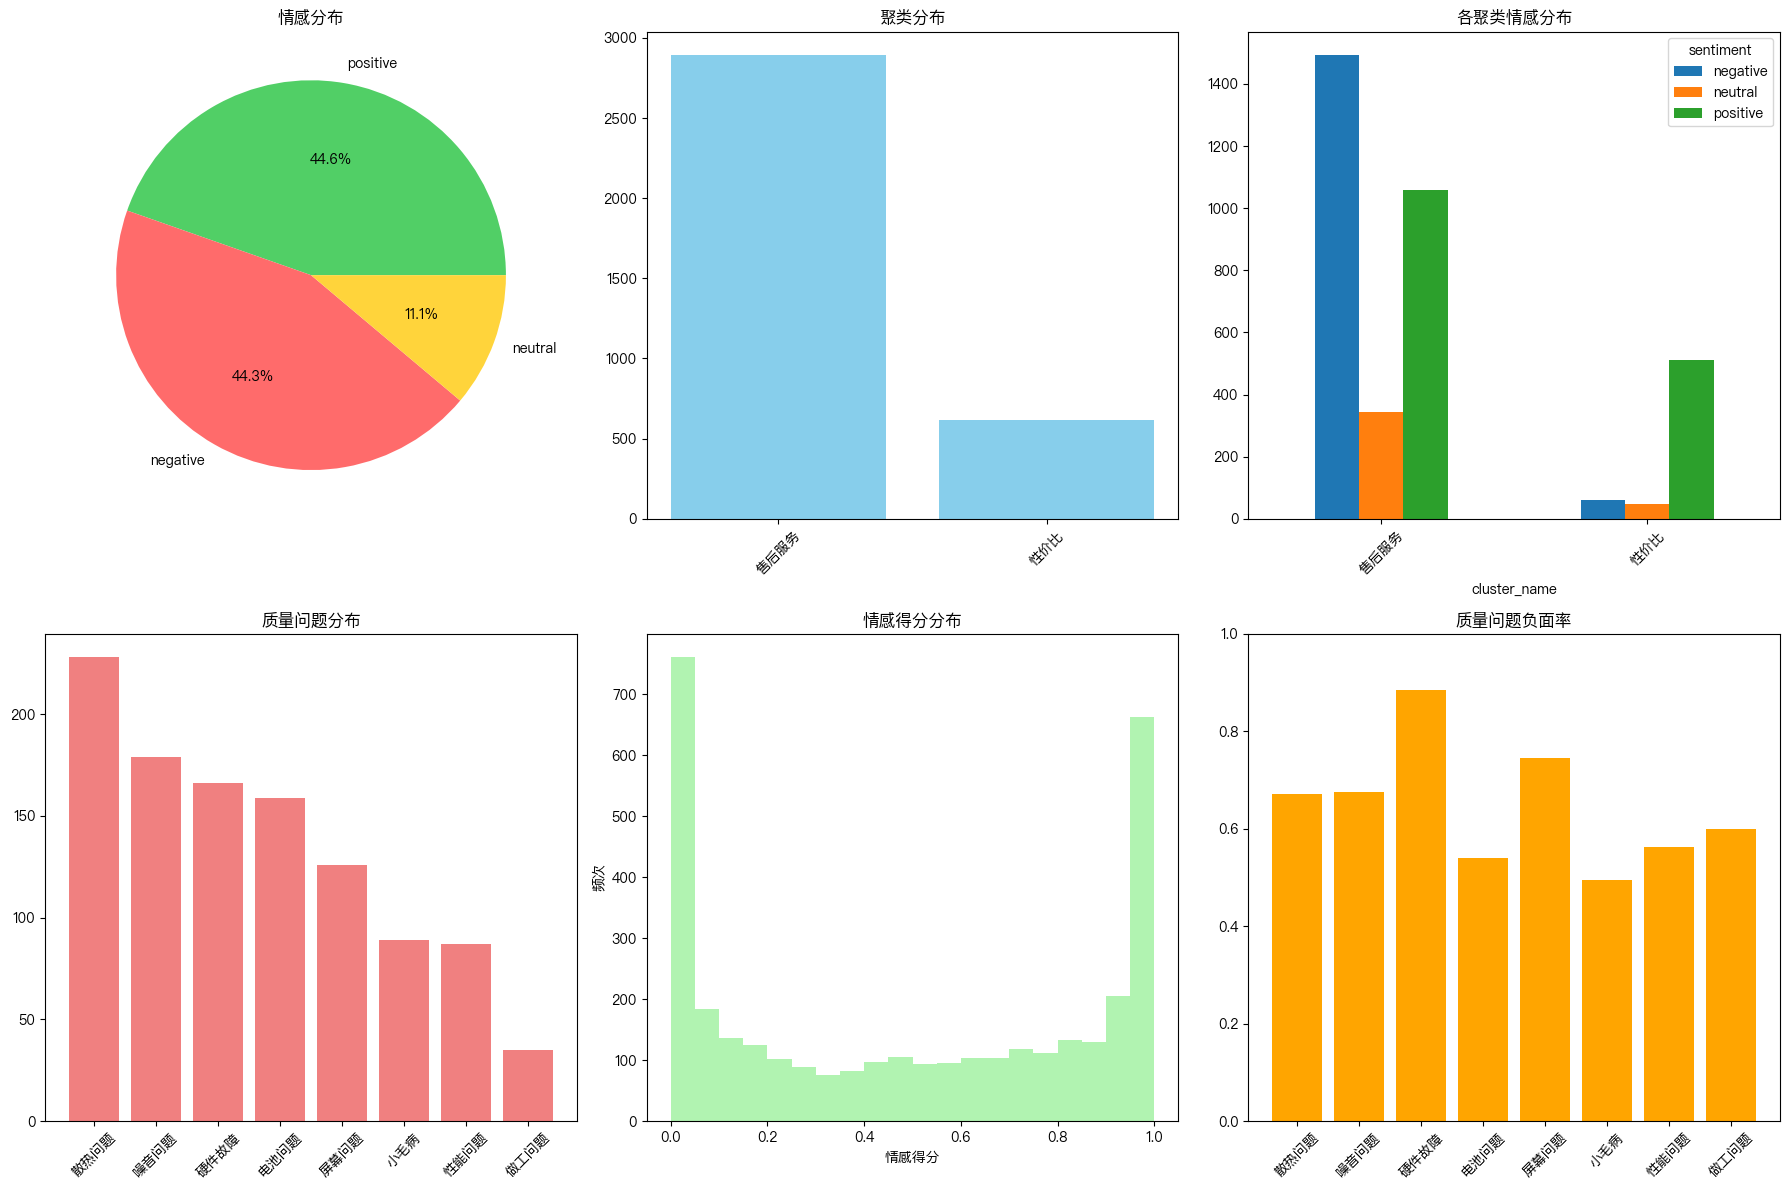


步骤8: 保存结果...
✓ 结果已保存到 quality_analysis_results.csv
  - 保存了 3514 条评论的分析结果
  - 包含列: nickname, cleaned_content, sentiment, sentiment_score, cluster, cluster_name, quality_issues

✓ 所有分析步骤完成！


In [29]:
# 可视化
print("=" * 60)
print("步骤7: 结果可视化...")
print("=" * 60)

# 先打印统计摘要
print("\n=== 分析结果摘要 ===")
sentiment_counts = df['sentiment'].value_counts()
print(f"\n1. 情感分布:")
for sentiment, count in sentiment_counts.items():
    percentage = count / len(df) * 100
    print(f"   {sentiment:8s}: {count:4d} 条 ({percentage:5.2f}%)")

cluster_counts = df['cluster_name'].value_counts()
print(f"\n2. 聚类分布:")
for name, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(f"   {name:20s}: {count:4d} 条 ({percentage:5.2f}%)")

all_issues = []
for issues in df['quality_issues']:
    all_issues.extend(issues)
if all_issues:
    issue_counts = pd.Series(all_issues).value_counts()
    print(f"\n3. 质量问题分布（前5名）:")
    for issue, count in issue_counts.head(5).items():
        percentage = count / len(df) * 100
        print(f"   {issue:8s}: {count:4d} 次 ({percentage:5.2f}%)")

print("\n正在生成可视化图表...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 情感分布饼图
sentiment_counts = df['sentiment'].value_counts()
colors = ['#51cf66', '#ff6b6b', '#ffd43b']
axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors)
axes[0, 0].set_title('情感分布')

# 2. 聚类分布柱状图
cluster_counts = df['cluster_name'].value_counts()
axes[0, 1].bar(cluster_counts.index, cluster_counts.values, color='skyblue')
axes[0, 1].set_title('聚类分布')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. 各聚类情感分布
cluster_sentiment = pd.crosstab(df['cluster_name'], df['sentiment'])
cluster_sentiment.plot(kind='bar', ax=axes[0, 2])
axes[0, 2].set_title('各聚类情感分布')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. 质量问题分布
all_issues = []
for issues in df['quality_issues']:
    all_issues.extend(issues)
if all_issues:
    issue_counts = pd.Series(all_issues).value_counts()
    axes[1, 0].bar(issue_counts.index, issue_counts.values, color='lightcoral')
    axes[1, 0].set_title('质量问题分布')
    axes[1, 0].tick_params(axis='x', rotation=45)

# 5. 情感得分分布
axes[1, 1].hist(df['sentiment_score'], bins=20, color='lightgreen', alpha=0.7)
axes[1, 1].set_title('情感得分分布')
axes[1, 1].set_xlabel('情感得分')
axes[1, 1].set_ylabel('频次')

# 6. 质量问题情感倾向
if all_issues:
    issue_sentiment = {}
    for issue in issue_counts.index[:8]:  # 显示前8个问题
        issue_data = df[df['quality_issues'].apply(lambda x: issue in x)]
        negative_ratio = len(issue_data[issue_data['sentiment'] == 'negative']) / len(issue_data) if len(issue_data) > 0 else 0
        issue_sentiment[issue] = negative_ratio
    
    axes[1, 2].bar(issue_sentiment.keys(), issue_sentiment.values(), color='orange')
    axes[1, 2].set_title('质量问题负面率')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 保存结果
print("\n" + "=" * 60)
print("步骤8: 保存结果...")
print("=" * 60)

output_df = df[['nickname', 'cleaned_content', 'sentiment', 'sentiment_score', 
                'cluster', 'cluster_name', 'quality_issues']]
output_df.to_csv('quality_analysis_results.csv', index=False, encoding='utf-8-sig')

print(f"✓ 结果已保存到 quality_analysis_results.csv")
print(f"  - 保存了 {len(output_df)} 条评论的分析结果")
print(f"  - 包含列: {', '.join(output_df.columns.tolist())}")

print("\n" + "=" * 60)
print("✓ 所有分析步骤完成！")
print("=" * 60)

In [30]:
## 分析说明
'''
本notebook包含完整的评论分析流程：

1. **数据读取**: 从 `clustered_data.csv` 读取数据
2. **文本预处理**: 使用jieba分词和文本清洗
3. **情感分析**: 使用SnowNLP进行情感分析
4. **质量问题检测**: 基于关键词检测8类质量问题
5. **聚类分析**: 使用TF-IDF + KMeans进行文本聚类（5个簇）
6. **结果可视化**: 生成6个可视化图表
7. **结果保存**: 保存到 `quality_analysis_results.csv`
'''

'\n本notebook包含完整的评论分析流程：\n\n1. **数据读取**: 从 `clustered_data.csv` 读取数据\n2. **文本预处理**: 使用jieba分词和文本清洗\n3. **情感分析**: 使用SnowNLP进行情感分析\n4. **质量问题检测**: 基于关键词检测8类质量问题\n5. **聚类分析**: 使用TF-IDF + KMeans进行文本聚类（5个簇）\n6. **结果可视化**: 生成6个可视化图表\n7. **结果保存**: 保存到 `quality_analysis_results.csv`\n'